# 2D Dynamics Analysis Notebook

Analyze energy, temp vs time.  Calculate translational and rotational diffusion.

In [1]:
import numpy as np
import os
import sys
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

import gzip
from scipy.spatial import KDTree
from utils.readsim import ReadSim
import utils.run_manager as rm
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

def find_midlayer_pt(result,frame):
    nshells = np.max(result.dump_mol)    # number of molecules in simulation
    molatoms = result.natoms/nshells    # number of atoms per molecule
    
    ri = []
    vi = []
    for i in np.arange(nshells):
        mol = i+1
        aid1 = int(molatoms/4 + (mol - 1)*molatoms)    # id of middle-most atom in bottom layer 
        aid2 = int(3*molatoms/4 + (mol - 1)*molatoms)    # id of middle-most atom in bottom layer 
        mask = (result.dump_mol[frame]==mol)    # molecule mask
        a1mask = (result.dump_id[frame][mask]==aid1)
        a2mask = (result.dump_id[frame][mask]==aid2)
        r1 = np.array([result.dump_x[frame][mask][a1mask][0], # position of bottom atom
                       result.dump_y[frame][mask][a1mask][0]])
        r2 = np.array([result.dump_x[frame][mask][a2mask][0],    # position of top atom
               result.dump_y[frame][mask][a2mask][0]])
        zdist = np.sqrt(np.sum((r2-r1)**2))
        vmol = (r2-r1)/zdist    # molecule orientation vector
        rmol = r1 + 0.5*zdist*vmol    # position of molecule center
        ri.append(rmol.tolist())
        vi.append(vmol.tolist())
    return np.array(ri), np.array(vi)

def find_stacks(result,frame,rcut):
    # returns list of aggregates 
    # result must have read dumpfile already

    nshells = np.max(result.dump_mol)
    box_x = result.xhi - result.xlo
    box_y = result.yhi - result.ylo
    rshift = 0.5*np.array(box_x,box_y)    # shift points so that box starts at (0,0)
    rm, vm = find_midlayer_pt(result,frame)
    tree = KDTree(rm+rshift,boxsize=2*rshift)
    
    done = []
    aggs = []
    for i in np.arange(nshells,dtype=int):    # Note: rm[0] is mol = 1 in LAMMPS
        if i not in done:
            done.append(i)
            agg_i = [i]    # indeces of molecules in same aggregate as mol i (i = index, not molid)
            ni_indeces = tree.query_ball_point((rm+rshift)[i],rcut)
            for j in ni_indeces:
                if (j != i)and(np.sum(vm[i]*vm[j])>0):                          
                    agg_i.append(j)
                    done.append(j)
                    nj_indeces = tree.query_ball_point((rm+rshift)[j],rcut)
                    for k in nj_indeces:
                        if (k not in ni_indeces)and(np.sum(vm[k]*vm[j])>0):
                            ni_indeces.append(k)
            aggs.append(agg_i)
            
    return aggs

# Select simulation

In [6]:
##### PARTICLE #####
### Geometry
dimension = 2
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
t0 = 0.6 * dcore    # structural thickness
wx = 4.9 * dcore    # shell width (arclength along midline)
r0 = 6.5 #"flat"  # set to "flat" for particles with zero curvature
Nbeads = 15    # number of beads per layer (2Nbeads is beads per curvamer)
fraction = 1/3    # middle patch of beads has width = fraction * wx

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0

### Elasticity
kh = 1000
nu = 0.3
d = wx/(Nbeads-1)   # bead spacing
alpha = t0/d
kvkh = 2*(1-alpha**2 * nu)/(alpha**2 - nu)
kckh = nu*(1 + alpha**2)/(alpha**2 - nu)

### Interactions
pair_ints = "1patch" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False
sigma = 0.25*dcore
epsilon = 0.11208258168520176
shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
wcacut = dcore    # cutoff distance for repulsive wca potential
softsigma = 5*sigma
softepsilon = 5e-8 * epsilon
softshift = 0 #softcore - 2**(1/6)*softsigma
softcut = 2**(1/6) * softsigma

##### SIMULATION #####
config = "dispersed" #"dispersed", "lattice", or "stacked"
simtype = "md"
datascript = "load"    # script to make data file with, NO .py EXTENSION, "stack", "load", or "lattice"
nshells = 400
datagz = True
trajgz = True
dumpbonds = False    # whether to calculate and dump bond data
screen = True    # output lammps log to screen


### Stacked config settings
#         k_i = 1.25 * k_0    # curvature of bottom shell in stack
#         xlo = -2*wx
#         xhi = 2*wx
#         ylo = -4*r0
#         yhi = nshells*r0 + 4*r0
#         zlo = -0.5
#         zhi = 0.5

### Lattice config settings
#            Nx = 10    # number of particle columns for initial config 
#            Ny = int(nshells/Nx)
#            nshells = int(Nx*Ny)   # true number of shells in simulation
#            k_i = 0    # initial curvature of shells in lattice (need flat for high concentrations)
#            theta = "random"   # orientation of shells in lattice (0 = concave down, np.pi = concave up, "random" = randomly up or down)

### Dispersed config settings
phi = 0.3 #0.005    # concentration of molecules (area fraction) - only for MD
v0 = wx * (t0 + dcore)    # approx area of monomer
lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
xlo = -lbox/2
xhi = lbox/2
ylo = -lbox/2
yhi = lbox/2
zlo = -0.5
zhi = 0.5

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-10
# maxiter = 100000

Tstart = 0.03
Tstop = Tstart
Tdamp = 10
seed = 15298
timestep = 0.0001
runsteps = 500*1000000

dumpfreq = 100*1000 #maxiter
thermofreq = 10*1000

#         force  = 0.1

##### LOGISTICS #####

### Simulation Directories
# delete_existing = True    # if True, deletes simulation directory (and .sh files) if it exists before creating again
## stack melt simpaths
# simpath = f"data/dynamics2D/{int(dimension)}d/md/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/stackmelts/r0-{r0}/pair_ints-{pair_ints}-soft_ints-{soft_ints}/nshells-{nshells}/sigma-{sigma:0.5f}/kh-{kh:0.5f}/damp-{Tdamp:0.3f}-dt-{timestep:0.7f}/kT-{Tstart:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)

## dispersed simulation simpaths
if r0 == "flat":
    simpath = f"data/dynamics2D/{int(dimension)}d/md/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/nshells-{nshells}/r0-{r0}/sigma-{sigma:0.5f}-kh-{kh:0.3f}/phi-{phi:0.3f}/kT-{Tstart:0.3f}/damp-{Tdamp:0.3f}"
else:
    simpath = f"data/dynamics2D/{int(dimension)}d/md/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/nshells-{nshells}/r0-{r0:0.3f}/sigma-{sigma:0.5f}-kh-{kh:0.3f}/phi-{phi:0.3f}/kT-{Tstart:0.3f}/damp-{Tdamp:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)

## single molecule simpaths
# simpath = f"data/dynamics2D/{int(dimension)}d/md/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/nshells-{nshells}/r0-{r0}/tests/kh-{kh:0.2f}-nu-{nu:0.3f}-dt-{timestep:0.5f}-m-1-damp-{Tdamp:0.2f}/phi-{phi:0.3f}-kT-{Tstart:0.3f}"

# Track Energies and Temperatures

In [7]:
# simpath = "data/dynamics2D/2d/md/wx-4.900-t0-0.300-Nbeads-15/stackmelts/r0-flat/pair_ints-1patch-soft_ints-False/nshells-10/sigma-0.25000/kh-500.00000/damp-1.000-dt-0.0001000/kT-0.020"
data = np.loadtxt(f"{PROJECT_ROOT}/{simpath}/energies.txt",skiprows=1,comments='#',unpack=True)
step, etotal, pe, ke, epair, ebond, temp = data


Text(0, 0.5, 'energy/Eadh')

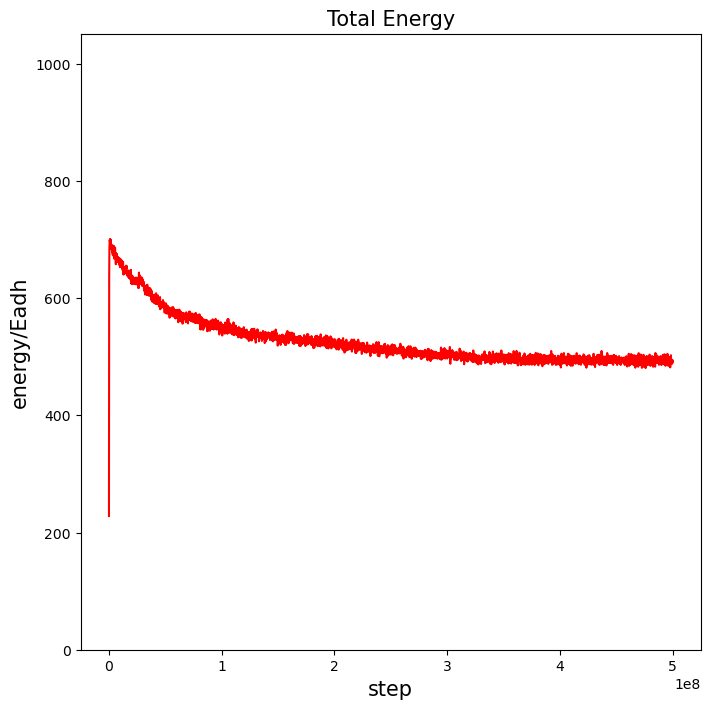

In [8]:
fig, ax = plt.subplots(1,1,figsize = (8,8))
ax.plot(step,etotal,"r")
ax.set_ylim(0,1.5*np.max(etotal))
ax.set_title("Total Energy",fontsize=15)
ax.set_xlabel("step",fontsize=15)
ax.set_ylabel("energy/Eadh",fontsize=15)

Text(0, 0.5, 'bond energy / Eadh')

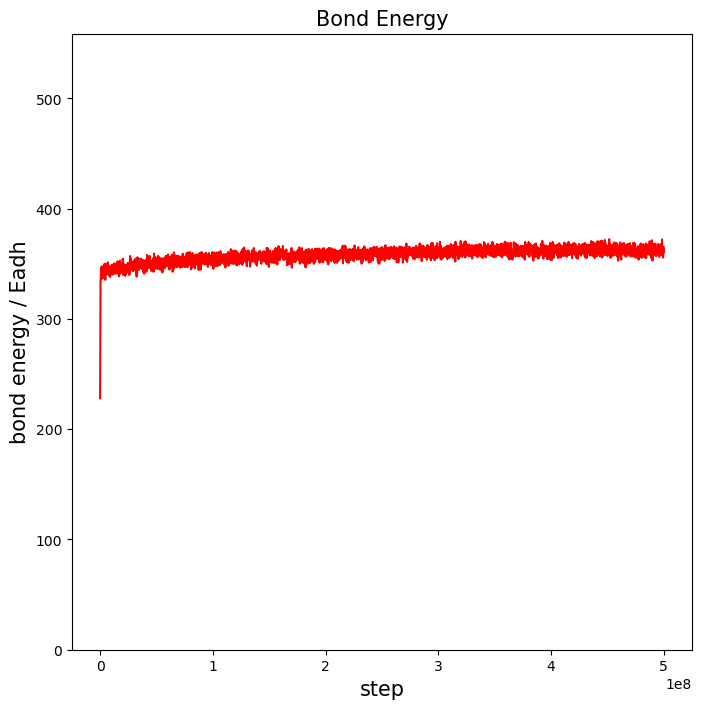

In [9]:
fig, ax = plt.subplots(1,1,figsize = (8,8))
ax.plot(step,ebond,"r")
ax.set_ylim(0,1.5*np.max(ebond))
ax.set_title("Bond Energy",fontsize=15)
ax.set_xlabel("step",fontsize=15)
ax.set_ylabel("bond energy / Eadh",fontsize=15)

Text(0, 0.5, 'k_B T / E_adh')

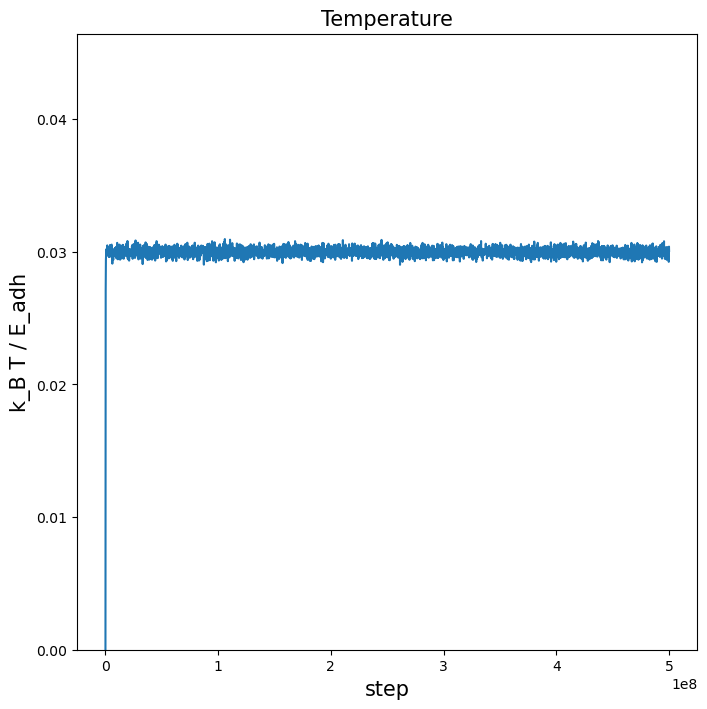

In [10]:
fig, ax = plt.subplots(1,1,figsize = (8,8))
ax.plot(step,temp)
ax.set_ylim(0,1.5*np.max(temp))
ax.set_title("Temperature",fontsize=15)
ax.set_xlabel("step",fontsize=15)
ax.set_ylabel("k_B T / E_adh",fontsize=15)

# Track Particles